In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [3]:
# Importamos el dataframe

df = pd.read_csv("files/vuelos_clientes.csv")
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1


Usando las herramientas de visualización que has aprendido durante este módulo, contesta a las siguientes
preguntas usando la mejor gráfica que consideres:

. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de

### ✈️¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

<Axes: xlabel='Month', ylabel='Flights Booked'>

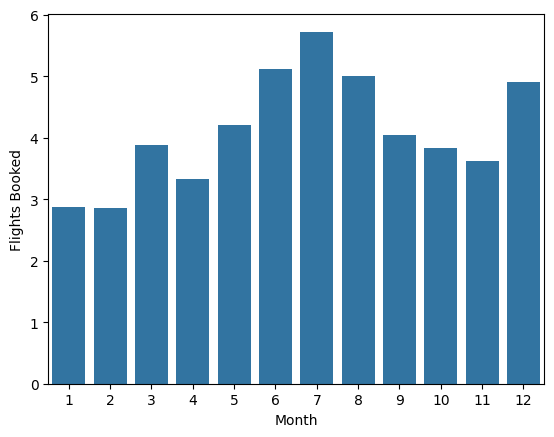

In [8]:
sns.barplot(data=df, y= "Flights Booked", x="Month", errorbar=None)

Como se evidencia en el countplot anterior, las temporadas más altas son en los meses de verano y las fiestas decembrinas, aunado a un pequeno repunte en marzo, que se debe a que las vacaciones escolares en Canada son entre marzo y abril. 


### 🌍 ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los clientes?

<Axes: xlabel='Points Accumulated', ylabel='Distance'>

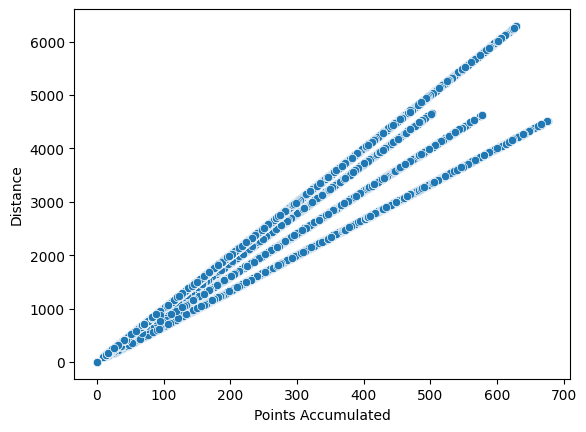

In [11]:
sns.scatterplot(data=df, x="Points Accumulated", y="Distance")

Es evidente que existe una correlacion alta y positiva entre ambas variables. A medida que aumenta la Distance (distancia volada), también aumentan los Points Accumulated (puntos acumulados). Esto tiene todo el sentido del mundo: cuanto más lejos vuelas, más puntos te regala la aerolínea. Sin embargo, hay un patrón de lineas que sugiere que hay otra variable mediando en esta relación entre como se dan los puntos y la distancia, procedemos con Loyalty Card, que es la variable categórica que más probablemente intervenga. 

<Axes: xlabel='Points Accumulated', ylabel='Distance'>

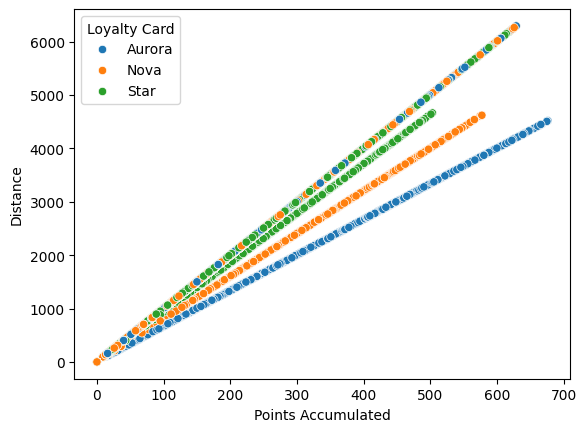

In [12]:
sns.scatterplot(data=df, x="Points Accumulated", y="Distance", hue= "Loyalty Card")

Se evidencia que Loyalty card tiene un papel muy importante en la acumulación de millas, mostrand tres lineas por separado, siendo la más eficiente Aurora (da más puntos por milla), y la más lenta Star. Adicionalmente hay otra línea bien diferenciada que se atribuye a otros factores. 

### 🏙️¿Cuál es la distribución de los clientes por provincia o estado?

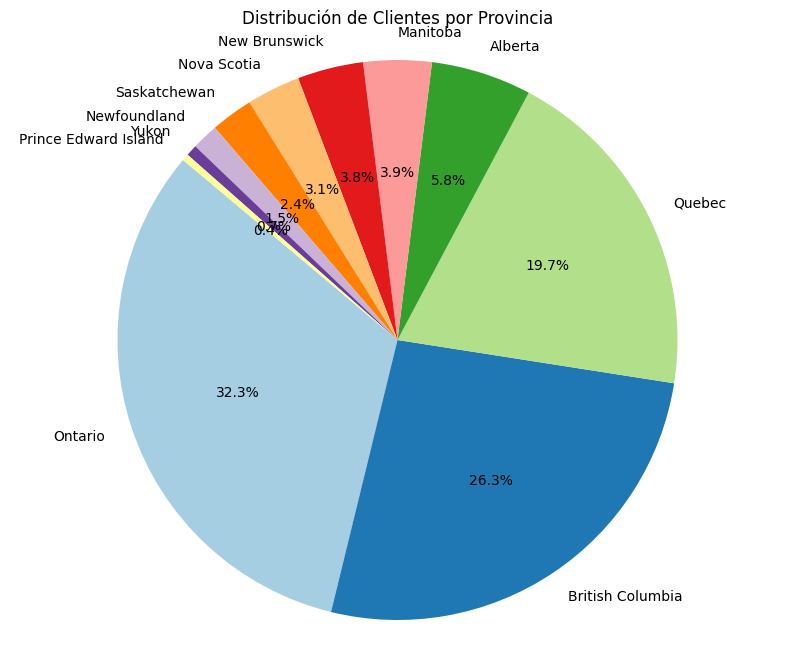

In [ ]:
# 1. Obtenemos los clientes únicos y contamos sus provincias
provincias = df.drop_duplicates('Loyalty Number')['Province'].value_counts()

# 2. Creamos el gráfico
plt.figure(figsize=(10, 8))
plt.pie(provincias, 
        labels = provincias.index, 
        autopct='%1.1f%%', # Esto añade el porcentaje con un decimal
        startangle=140,    # Gira el gráfico para que se vea mejor
        colors=plt.cm.Paired.colors) 

plt.title('Distribución de Clientes por Provincia')
plt.axis('equal') # Asegura que el gráfico sea un círculo perfecto
plt.show()

Haciendo un grafico de tarta o quesitos rapidamente podemos identificar que la gran mayoria de los clientes vienen de Ontario, British Columbia y Quebec. El resto de las provincias estan distribuidas en mucha menor proporción. 

### 💵🎓¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

<Axes: xlabel='Education', ylabel='Salary'>

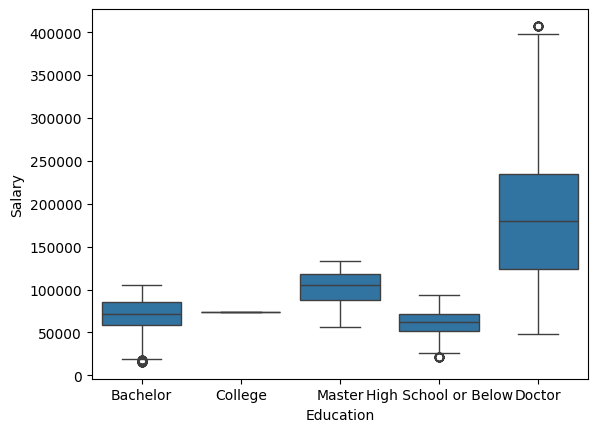

In [26]:
sns.boxplot(x = "Education",
            y = "Salary", 
            data = df)

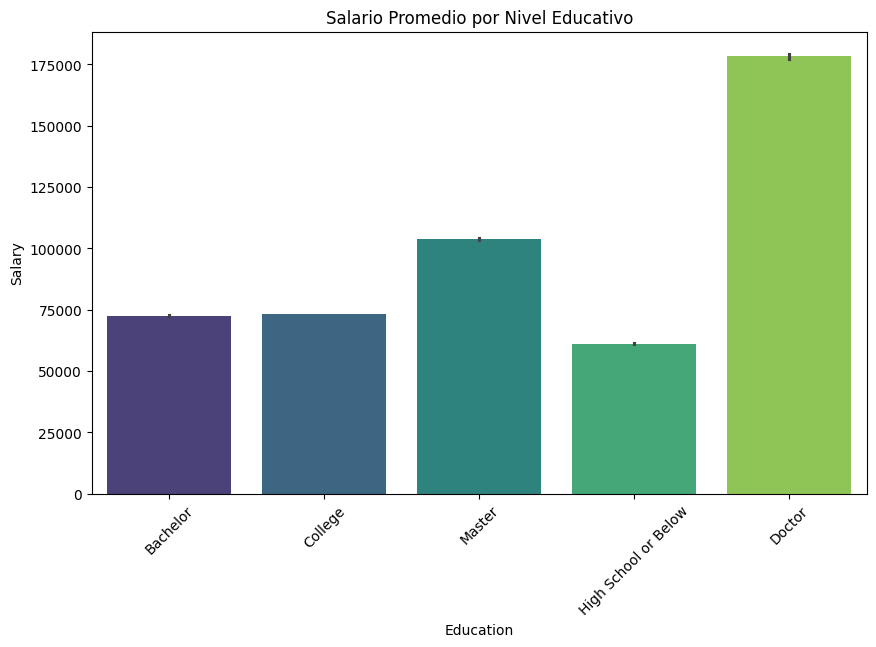

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Education', y='Salary', palette='viridis', estimator='mean')

plt.title('Salario Promedio por Nivel Educativo')
plt.xticks(rotation=45)
plt.show()

Usamos los dos métodos de visualización para comparar dispersión, distribución de valores y media vs mediana. En todos se evidencia que el promedio o mediana de salario incrementa a nivel que sube el nivel educativo, desde educación secundaria hasta el Doctor, siendo este último el que más gana y que mayores outliers tiene en el rango superior. Doctor tiene efectivamente los mayores salarios, pero también la mayor dispersión, dado que los valores se distribuyen a través de casi todo el rango. 
El resto de los niveles educativos están bastante igualados en comparación, teniendo un incremento un poco superior en la categoría de Master.

### 💳👨‍👩‍👧‍👦 ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

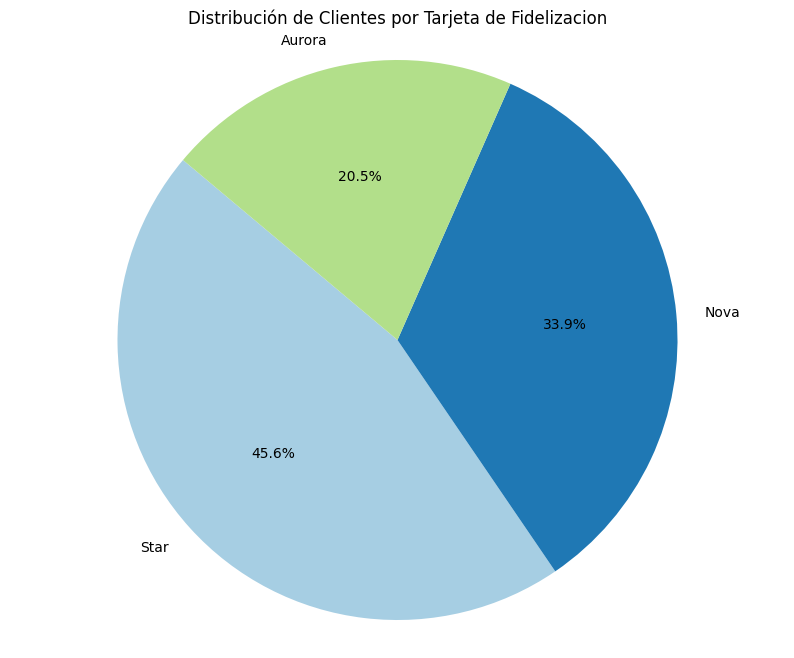

In [30]:
# 1. Obtenemos los clientes únicos y contamos
fidelidad = df.drop_duplicates('Loyalty Number')['Loyalty Card'].value_counts()

# 2. Creamos el gráfico
plt.figure(figsize=(10, 8))
plt.pie(fidelidad, 
        labels = fidelidad.index, 
        autopct='%1.1f%%', # Esto añade el porcentaje con un decimal
        startangle=140,    # Gira el gráfico para que se vea mejor
        colors=plt.cm.Paired.colors) 

plt.title('Distribución de Clientes por Tarjeta de Fidelizacion')
plt.axis('equal') # Asegura que el gráfico sea un círculo perfecto
plt.show()

Con el grafico de tarta podemos ver que casi la mitad de los clientes, dado que estamos contando valores únicos, pertenecen al programa Star. El segundo más comun es Nova y el último es Aurora. Dado que ya hemos comprobado que Aurora era la categoría que daba más puntos por milla, tiene sentido que sea la más exclusiva, sólo para eltop 20% de los clientes. 

### 💍🤵‍♀️🤵‍♂️¿Cómo se distribuyen los clientes según su estado civil y género?


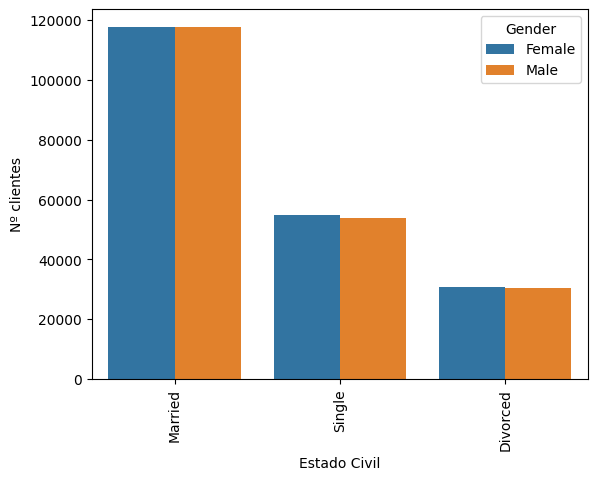

In [33]:
sns.countplot(x = "Marital Status", 
              data = df, 
              hue = "Gender")

# giramos las etiquetas del eje "x",  
plt.xticks(rotation = 90)

# cambiamos el nombre de los ejes usando los métodos 'plt.ylabel()' y 'plt.xlabel()'
plt.xlabel("Estado Civil")
plt.ylabel("Nº clientes"); 

Una gran proporción de los clientes son casados, con casi 120.000 de cada género perteneciente a ese sector. Eso nos hace concluir que el cliente principal de la aereolínea son familias o parejas, que tienen estabilidad financiera y hacen una palnificación mayor. 
Le siguen los solteros y en mucha menor proporción los divorciados. 
A nivel de género, la distribución es casi igual en ambos, con un ligero dominio de las mujeres en los segmentos. 

### 🎓✈️  Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo

In [52]:
#Primero filtramos las columnas que queremos utilizar

df_bonus = df[["Flights Booked", "Education"]].copy()
df_bonus = df_bonus.reset_index(drop=True)
df_bonus.head()


,Flights Booked,Education
0,3,Bachelor
1,10,College
2,6,College
3,0,Bachelor
4,0,Bachelor


Análisis Descriptivo: Agrupa los datos por nivel educativo y calcula estadísticas descriptivas
básicas (como el promedio, la desviación estándar) del número de vuelos reservados para cada
grupo.
=

In [66]:
reporte_education = df_bonus.groupby('Education')[['Flights Booked']].agg(['mean', 'median', 'std', 'min', 'max'])

display(reporte_education)

Flights Booked                         
                               mean median       std min max
Education                                                   
Bachelor                   4.091691    1.0  5.216549   0  21
College                    4.153012    1.0  5.242136   0  21
Doctor                     4.146281    1.0  5.250093   0  21
High School or Below       4.157975    1.0  5.235462   0  21
Master                     4.184014    1.0  5.210294   0  21

In [73]:
reporte_education = reporte_education.reset_index

In [75]:
reporte_education()

Education Flights Booked                         
                                  mean median       std min max
0              Bachelor       4.091691    1.0  5.216549   0  21
1               College       4.153012    1.0  5.242136   0  21
2                Doctor       4.146281    1.0  5.250093   0  21
3  High School or Below       4.157975    1.0  5.235462   0  21
4                Master       4.184014    1.0  5.210294   0  21

Podemos observar que la distribución es bastante homogénea. La media de todos los niveles educativos coincide a nivel de reservas de vuelo, y el comportamiento de la variable en general se conserva, con el 50% de los datos por debajo de 1 vuelo reservado y una dispersión similar. 
Reproduciremos un box plot para confirmar lo que nos dice la tabla. 

<Axes: xlabel='Education', ylabel='Flights Booked'>

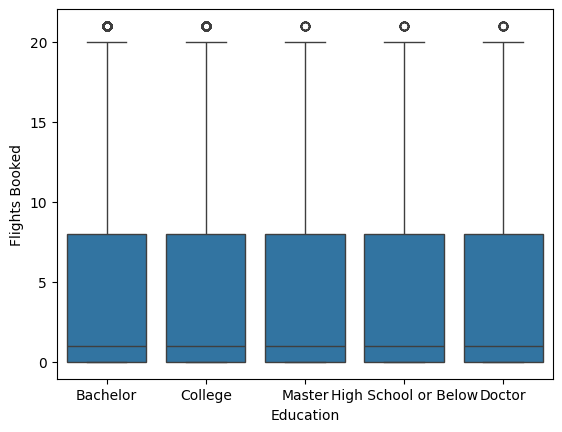

In [67]:
sns.boxplot(x = "Education",
            y = "Flights Booked", 
            data = df_bonus)

En general en todos los casos se observa mucha dispersión, con un 25% de los datos entre 5 y 20 vuelos reservados. No pareciera ser que la educación influencie los vuelos reservados por si sola, pero pudiese ser una variable mediadora. 
Para explorar esa posibilidad vamos al dataframe original y exploramos si gente con mayor salario reserva mas vuelos. 
La respuesta es que no, si bien es claro el cambio de nivel educativo por salario, pareciera ser que esto no influye en la cantidad de vuelos reservados de los clientes 


<Axes: xlabel='Flights Booked', ylabel='Salary'>

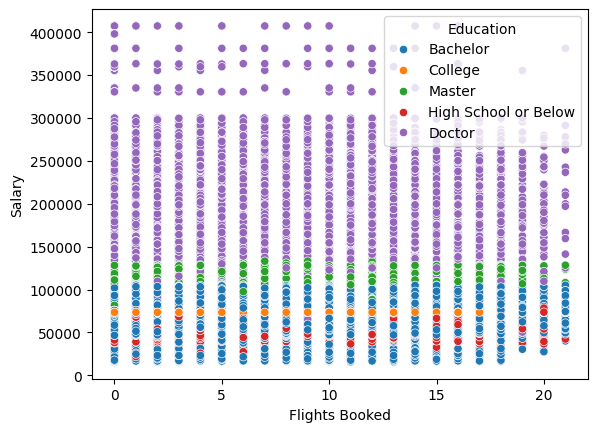

In [79]:
sns.scatterplot(data=df, x="Flights Booked", y="Salary", hue="Education")